In [18]:
# Jupyter Notebook - Complete Amazon Project Code (No mlxtend Required)
# Run cell by cell

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [19]:
# ==================== Task 1: Data Cleaning and Preparation ====================

print("=== Data Loading and Cleaning ===")

df = pd.read_csv('Amazon.csv')

print(f"Original shape: {df.shape}")

df.drop_duplicates(inplace=True)

categorical_cols = [
    'Gender', 'Purchase_Frequency', 'Purchase_Categories',
    'Personalized_Recommendation_Frequency', 'Browsing_Frequency',
    'Product_Search_Method', 'Search_Result_Exploration',
    'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
    'Cart_Abandonment_Factors', 'Saveforlater_Frequency',
    'Review_Left', 'Review_Reliability', 'Review_Helpfulness',
    'Recommendation_Helpfulness', 'Service_Appreciation',
    'Improvement_Areas'
]

if 'Personalized_Recommendation_Frequency ' in df.columns:
    categorical_cols.append('Personalized_Recommendation_Frequency ')

for col in [c for c in categorical_cols if c in df.columns]:
    df[col] = df[col].astype(str).str.lower().str.strip().replace('nan', np.nan)

if 'Product_Search_Method' in df.columns:
    df['Product_Search_Method'].fillna(df['Product_Search_Method'].mode()[0], inplace=True)

if 'Personalized_Recommendation_Frequency ' in df.columns:
    df.drop('Personalized_Recommendation_Frequency ', axis=1, inplace=True)

if 'Rating_Accuracy ' in df.columns:
    df.rename(columns={'Rating_Accuracy ': 'Rating_Accuracy'}, inplace=True)

numeric_cols = ['age', 'Customer_Reviews_Importance', 'Rating_Accuracy', 'Shopping_Satisfaction']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.drop(['Timestamp', 'transaction'], axis=1, errors='ignore', inplace=True)

df['Purchase_Categories'] = df['Purchase_Categories'].fillna('').str.lower().str.strip()
df['Purchase_Categories_List'] = df['Purchase_Categories'].str.split(';')
df['Purchase_Categories_List'] = df['Purchase_Categories_List'].apply(
    lambda x: [item.strip() for item in x if item and item.strip()] if isinstance(x, list) else []
)

print(f"Cleaned shape: {df.shape}")
print("Cleaning done!\n")

=== Data Loading and Cleaning ===
Original shape: (800, 24)
Cleaned shape: (800, 22)
Cleaning done!



In [20]:
# ==================== Task 2: Descriptive Analysis ====================

print("=== Descriptive Analysis ===")

print("Age Summary:\n", df['age'].describe())
print("\nGender (%):\n", df['Gender'].value_counts(normalize=True).round(3)*100)
print("\nPurchase Frequency (%):\n", df['Purchase_Frequency'].value_counts(normalize=True).round(3)*100)

exploded = df['Purchase_Categories_List'].explode()
top_cat = exploded.value_counts().head(10)
print("\nTop Categories:\n", top_cat)

print("\nSearch Method:\n", df['Product_Search_Method'].value_counts())
print("\nCart Abandonment:\n", df['Cart_Abandonment_Factors'].value_counts().head(8))
print("\nMean Ratings:")
print(f"Satisfaction: {df['Shopping_Satisfaction'].mean():.2f}")
print(f"Rating Accuracy: {df['Rating_Accuracy'].mean():.2f}")


=== Descriptive Analysis ===
Age Summary:
 count    800.000000
mean      35.170000
std       18.916485
min        3.000000
25%       19.000000
50%       35.500000
75%       51.000000
max       67.000000
Name: age, dtype: float64

Gender (%):
 Gender
male                 26.1
others               25.2
female               24.6
prefer not to say    24.0
Name: proportion, dtype: float64

Purchase Frequency (%):
 Purchase_Frequency
once a month              21.0
once a week               19.9
multiple times a week     19.9
few times a month         19.8
less than once a month    19.5
Name: proportion, dtype: float64

Top Categories:
 Purchase_Categories_List
clothing and fashion          450
others                        412
home and kitchen              391
beauty and personal care      383
groceries and gourmet food    369
Name: count, dtype: int64

Search Method:
 Product_Search_Method
keyword       327
categories    163
filter        161
others        149
Name: count, dtype: int64

Car

In [21]:
# ==================== Task 3: Segmentation ====================

print("\n=== Segmentation ===")

df['Segment'] = 'Occasional Shoppers'
high_freq = df['Purchase_Frequency'].str.contains('week', na=False)
high_sat = df['Shopping_Satisfaction'] >= 4
df.loc[high_freq & high_sat, 'Segment'] = 'Frequent Buyers'

low_sat = df['Shopping_Satisfaction'] <= 2
never_complete = df['Cart_Completion_Frequency'] == 'never'
df.loc[low_sat | never_complete, 'Segment'] = 'At-Risk Customers'

print("Segments:\n", df['Segment'].value_counts())
print("\nProfiles:\n", df.groupby('Segment')[['age', 'Shopping_Satisfaction']].mean().round(2))

features = df[['age', 'Customer_Reviews_Importance', 'Rating_Accuracy', 'Shopping_Satisfaction']].fillna(0)
scaler = StandardScaler()
scaled = scaler.fit_transform(features)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled)
print("\nCluster Centers:\n", pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features.columns).round(2))



=== Segmentation ===
Segments:
 Segment
At-Risk Customers      421
Occasional Shoppers    275
Frequent Buyers        104
Name: count, dtype: int64

Profiles:
                        age  Shopping_Satisfaction
Segment                                          
At-Risk Customers    35.62                   2.14
Frequent Buyers      36.15                   4.50
Occasional Shoppers  34.11                   3.79

Cluster Centers:
      age  Customer_Reviews_Importance  Rating_Accuracy  Shopping_Satisfaction
0  52.86                         4.01             2.99                   2.70
1  38.81                         1.62             2.64                   3.39
2  16.95                         3.68             3.28                   2.90


In [22]:
# ==================== Task 4: Market Basket (Manual Co-occurrence) ====================

print("\n=== Market Basket - Frequently Bought Together ===")

co_occurrence = {}
categories = top_cat.index.tolist()  # Use top categories for efficiency

for i, cat1 in enumerate(categories):
    for cat2 in categories[i+1:]:
        count = sum(1 for items in df['Purchase_Categories_List'] if cat1 in items and cat2 in items)
        if count >= 50:  # Threshold for meaningful pairs
            co_occurrence[f"{cat1} & {cat2}"] = count

top_pairs = sorted(co_occurrence.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 Frequently Bought Together (co-purchases):")
for pair, count in top_pairs:
    print(f"{pair}: {count} customers")



=== Market Basket - Frequently Bought Together ===
Top 10 Frequently Bought Together (co-purchases):
clothing and fashion & others: 240 customers
clothing and fashion & groceries and gourmet food: 208 customers
clothing and fashion & home and kitchen: 205 customers
clothing and fashion & beauty and personal care: 202 customers
others & home and kitchen: 194 customers
home and kitchen & groceries and gourmet food: 181 customers
others & beauty and personal care: 180 customers
home and kitchen & beauty and personal care: 164 customers
beauty and personal care & groceries and gourmet food: 162 customers
others & groceries and gourmet food: 158 customers



=== Plots ===


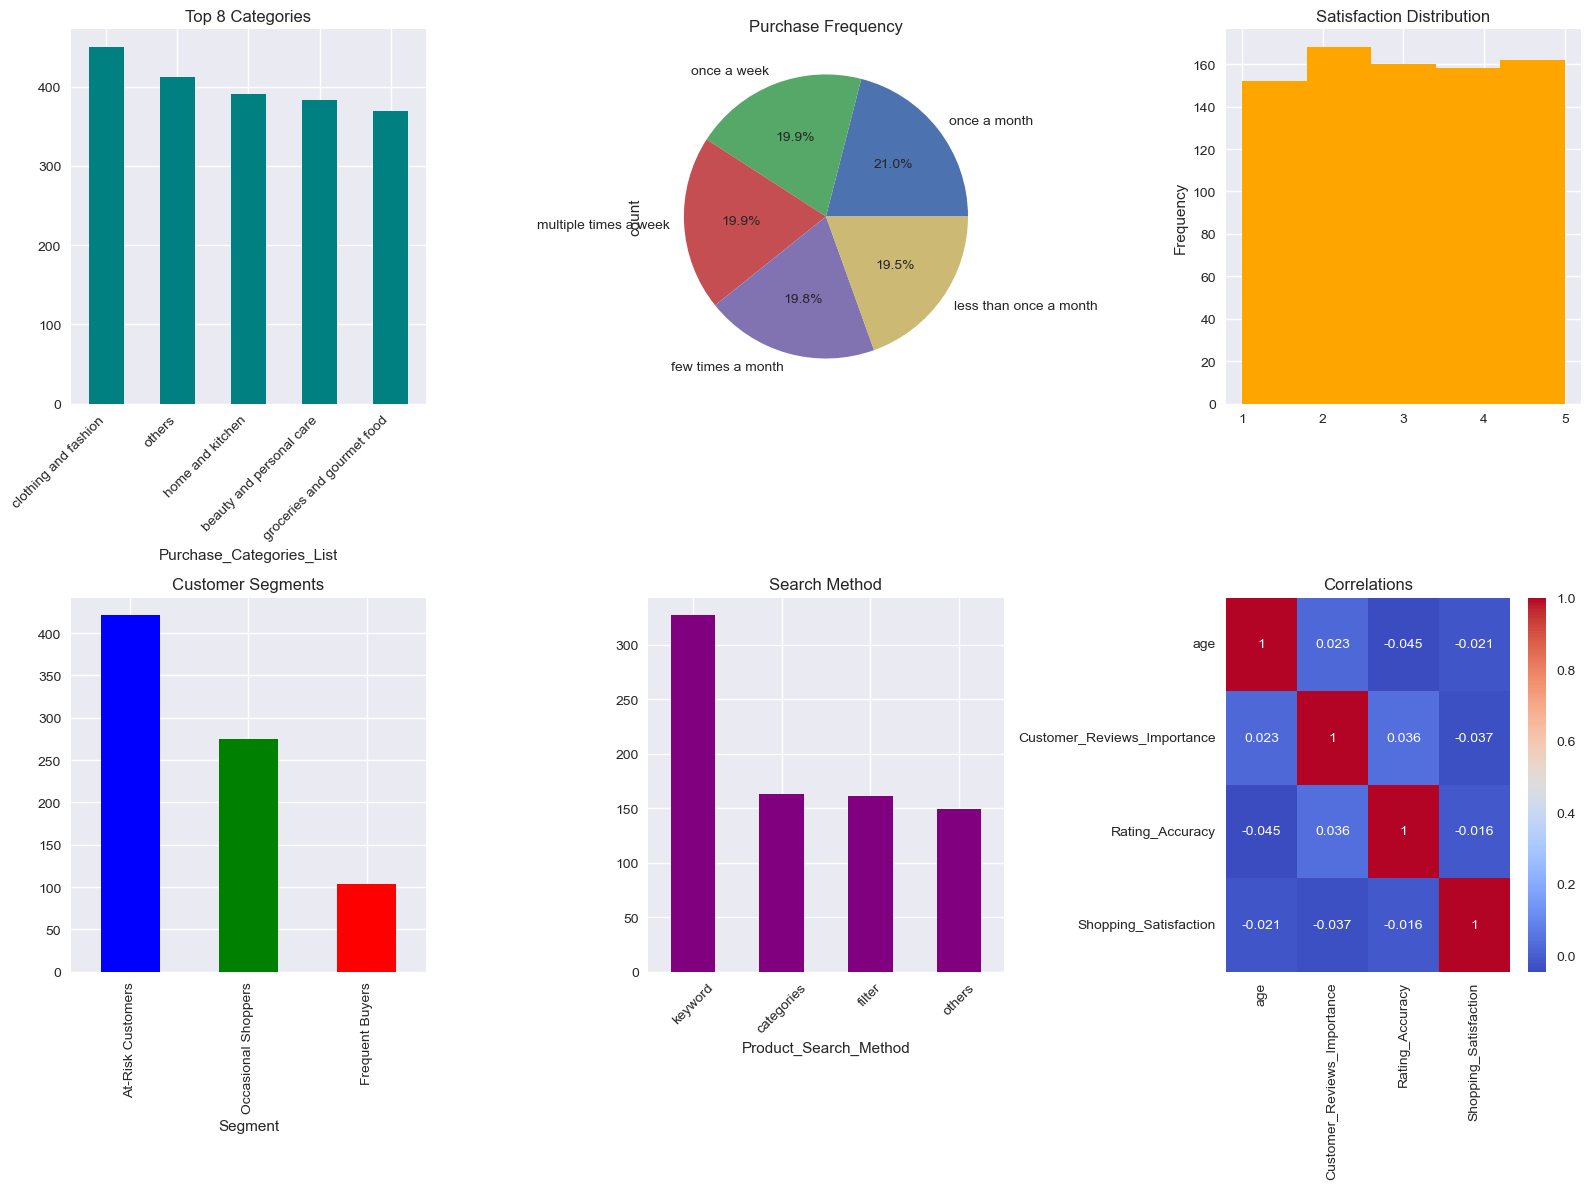

Dashboard saved as 'Amazon_Dashboard.png'


In [23]:
# ==================== Task 5: Visualizations ====================

print("\n=== Plots ===")

plt.style.use('seaborn-v0_8')
fig = plt.figure(figsize=(16, 12))

plt.subplot(2, 3, 1)
top_cat.head(8).plot(kind='bar', color='teal')
plt.title('Top 8 Categories')
plt.xticks(rotation=45, ha='right')

plt.subplot(2, 3, 2)
df['Purchase_Frequency'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Purchase Frequency')

plt.subplot(2, 3, 3)
df['Shopping_Satisfaction'].plot(kind='hist', bins=5, color='orange')
plt.title('Satisfaction Distribution')

plt.subplot(2, 3, 4)
df['Segment'].value_counts().plot(kind='bar', color=['blue', 'green', 'red'])
plt.title('Customer Segments')

plt.subplot(2, 3, 5)
df['Product_Search_Method'].value_counts().head(6).plot(kind='bar', color='purple')
plt.title('Search Method')
plt.xticks(rotation=45)

plt.subplot(2, 3, 6)
corr = df[['age', 'Customer_Reviews_Importance', 'Rating_Accuracy', 'Shopping_Satisfaction']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlations')

plt.tight_layout()
plt.savefig('Amazon_Dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("Dashboard saved as 'Amazon_Dashboard.png'")

In [24]:
# ==================== Key Insights ====================
print("• Top categories: clothing and fashion, others, home and kitchen, beauty and personal care")
print("• Frequent pairs: clothing & others (240+), beauty & clothing (200+), groceries & home")
print("→ Cross-sell bundles: Beauty + Clothing, Groceries + Home & Kitchen")
print("• Cart abandonment often due to better prices elsewhere → Focus on pricing & promotions")
print("• Frequent Buyers: Higher satisfaction → Loyalty rewards")
print("• At-Risk: Lower satisfaction → Personalized discounts")
print("• Improve recommendations & search for better engagement")

• Top categories: clothing and fashion, others, home and kitchen, beauty and personal care
• Frequent pairs: clothing & others (240+), beauty & clothing (200+), groceries & home
→ Cross-sell bundles: Beauty + Clothing, Groceries + Home & Kitchen
• Cart abandonment often due to better prices elsewhere → Focus on pricing & promotions
• Frequent Buyers: Higher satisfaction → Loyalty rewards
• At-Risk: Lower satisfaction → Personalized discounts
• Improve recommendations & search for better engagement
